# Classificação da Qualidade de Vinhos com Machine Learning

## Sumário do Projeto

1. Compreensão do Problema  
2. Análise Exploratória de Dados — EDA  
3. Pré-processamento dos Dados  
4. Desenvolvimento de Modelos  
5. Avaliação dos Modelos  
6. Interpretação dos Resultados  
7. Conclusão Final  

## 1. Compreensão do Problema

A indústria vitivinícola possui grande relevância econômica e cultural. Tradicionalmente, a avaliação da qualidade de um vinho é realizada por especialistas, considerando características sensoriais como aroma, sabor, acidez e equilíbrio. No entanto, esse processo pode ser subjetivo, demorado e dependente da experiência dos avaliadores.

Neste projeto, o objetivo é utilizar dados físico-químicos dos vinhos para desenvolver um modelo de Machine Learning capaz de prever se uma amostra pode ser classificada como de alta qualidade ou de baixa/média qualidade.

A variável original quality representa a nota atribuída ao vinho. Para simplificar o problema, essa variável será transformada em uma classificação binária:

1 — vinho de alta qualidade: nota maior ou igual a 7;

0 — vinho de baixa/média qualidade: nota menor que 7.

Dessa forma, o problema será tratado como uma tarefa de classificação binária.

In [1]:
# Importação das bibliotecas principais

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/WineQT.csv")

df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [3]:
# Verificando a quantidade de linhas e colunas

df.shape

(1143, 13)

In [4]:
# Visualizando os nomes das colunas

df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality', 'Id'],
      dtype='str')

In [5]:
# Informações gerais sobre a base

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


In [6]:
# Verificando valores faltantes

df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

A análise inicial da base indica que não existem valores faltantes nas colunas disponíveis. Isso significa que, nesta etapa, não será necessário aplicar técnicas de tratamento de dados ausentes, como exclusão de registros ou imputação de valores.

Além disso, a coluna Id não será utilizada como variável preditora na modelagem, pois representa apenas um identificador da amostra e não uma característica físico-química do vinho. No entanto, ela pode ser mantida na base para fins de rastreabilidade dos registros.

In [7]:
# Criação da variável alvo binária

df["alta_qualidade"] = np.where(df["quality"] >= 7, 1, 0)

df[["quality", "alta_qualidade"]].head()

,quality,alta_qualidade
0,5,0
1,5,0
2,5,0
3,6,0
4,5,0


In [8]:
# Distribuição da variável original quality

df["quality"].value_counts().sort_index()

quality
3      6
4     33
5    483
6    462
7    143
8     16
Name: count, dtype: int64

In [9]:
# Distribuição da variável alvo binária

df["alta_qualidade"].value_counts()

alta_qualidade
0    984
1    159
Name: count, dtype: int64

In [10]:
# Distribuição percentual da variável alvo

df["alta_qualidade"].value_counts(normalize=True) * 100

alta_qualidade
0    86.089239
1    13.910761
Name: proportion, dtype: float64

A variável alvo apresenta desbalanceamento entre as classes. A maior parte dos vinhos está classificada como baixa/média qualidade, representando aproximadamente 86% da base. Já os vinhos de alta qualidade representam cerca de 14% dos registros.

Esse desbalanceamento é importante para a etapa de modelagem, pois um modelo pode apresentar boa acurácia apenas por prever majoritariamente a classe mais frequente. Por isso, além da acurácia, serão utilizadas métricas como precision, recall, F1-score, matriz de confusão e ROC-AUC para avaliar melhor a capacidade dos modelos em identificar vinhos de alta qualidade.


## 2. Análise Exploratória de Dados — EDA

Nesta etapa, será realizada uma análise exploratória da base de dados com o objetivo de compreender melhor o comportamento das variáveis, a distribuição da qualidade dos vinhos, o balanceamento das classes, as correlações entre as variáveis e a presença de possíveis outliers.

Essa etapa é importante porque permite identificar padrões iniciais nos dados antes da construção dos modelos de Machine Learning.

In [11]:
# Lista de variáveis físico-químicas que serão usadas na análise

variaveis = [
    "fixed acidity",
    "volatile acidity",
    "citric acid",
    "residual sugar",
    "chlorides",
    "free sulfur dioxide",
    "total sulfur dioxide",
    "density",
    "pH",
    "sulphates",
    "alcohol"
]

In [12]:
# Estatísticas descritivas das variáveis numéricas

df[variaveis + ["quality"]].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1143.0,8.31,1.75,4.60,7.10,7.90,9.10,15.90
volatile acidity,1143.0,0.53,0.18,0.12,0.39,0.52,0.64,1.58
citric acid,1143.0,0.27,0.20,0.00,0.09,0.25,0.42,1.00
residual sugar,1143.0,2.53,1.36,0.90,1.90,2.20,2.60,15.50
chlorides,1143.0,0.09,0.05,0.01,0.07,0.08,0.09,0.61
free sulfur dioxide,1143.0,15.62,10.25,1.00,7.00,13.00,21.00,68.00
total sulfur dioxide,1143.0,45.91,32.78,6.00,21.00,37.00,61.00,289.00
density,1143.0,1.00,0.00,0.99,1.00,1.00,1.00,1.00
pH,1143.0,3.31,0.16,2.74,3.20,3.31,3.40,4.01
sulphates,1143.0,0.66,0.17,0.33,0.55,0.62,0.73,2.00


A análise descritiva permite observar a escala e a dispersão das variáveis físico-químicas dos vinhos. Algumas variáveis apresentam valores máximos consideravelmente acima da média, como `residual sugar`, `chlorides`, `free sulfur dioxide` e `total sulfur dioxide`, o que pode indicar a presença de outliers.

Também é possível observar que a variável `quality` está concentrada principalmente entre as notas 5 e 6, indicando que a maior parte das amostras recebeu avaliações intermediárias.

In [13]:
# Distribuição da variável quality

distribuicao_quality = df["quality"].value_counts().sort_index()

distribuicao_quality

quality
3      6
4     33
5    483
6    462
7    143
8     16
Name: count, dtype: int64

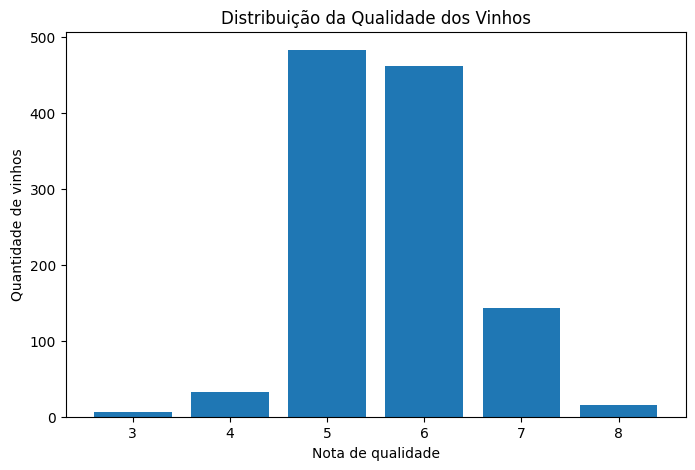

In [14]:
# Gráfico da distribuição da qualidade dos vinhos

plt.figure(figsize=(8, 5))
plt.bar(distribuicao_quality.index, distribuicao_quality.values)
plt.title("Distribuição da Qualidade dos Vinhos")
plt.xlabel("Nota de qualidade")
plt.ylabel("Quantidade de vinhos")
plt.xticks(distribuicao_quality.index)
plt.show()

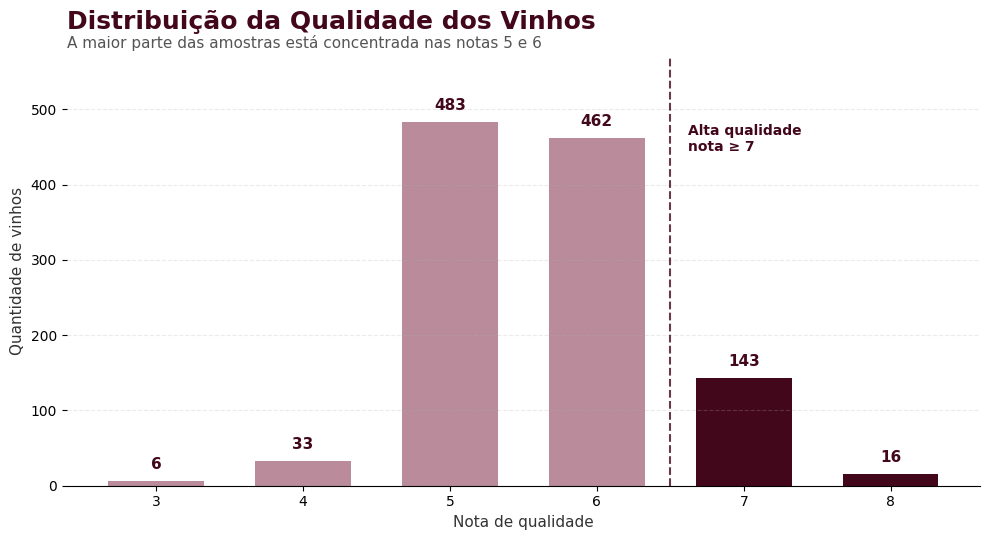

In [15]:
# Gráfico executivo - Distribuição da Qualidade dos Vinhos
cor_principal = "#43071b"
cor_secundaria = "#b98b9b"
cor_fundo = "#f8f3f5"

# Preparando os dados
distribuicao_quality = df["quality"].value_counts().sort_index()

# Criando a figura
fig, ax = plt.subplots(figsize=(10, 5.5))

# Cores das barras
# Notas 7 e 8 representam alta qualidade, então ficam na cor principal
cores_barras = [
    cor_principal if nota >= 7 else cor_secundaria
    for nota in distribuicao_quality.index
]

# Criando as barras
barras = ax.bar(
    distribuicao_quality.index,
    distribuicao_quality.values,
    color=cores_barras,
    width=0.65
)

# Adicionando os valores acima das barras
for barra in barras:
    altura = barra.get_height()
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        altura + 12,
        f"{int(altura)}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
        color=cor_principal
    )

# Título principal
ax.set_title(
    "Distribuição da Qualidade dos Vinhos",
    fontsize=18,
    fontweight="bold",
    color=cor_principal,
    loc="left",
    pad=20
)

# Subtítulo
ax.text(
    0,
    1.02,
    "A maior parte das amostras está concentrada nas notas 5 e 6",
    transform=ax.transAxes,
    fontsize=11,
    color="#555555"
)

# Destaque para alta qualidade
ax.axvline(
    x=6.5,
    color=cor_principal,
    linestyle="--",
    linewidth=1.5,
    alpha=0.8
)

ax.text(
    6.62,
    max(distribuicao_quality.values) * 0.92,
    "Alta qualidade\nnota ≥ 7",
    fontsize=10,
    color=cor_principal,
    fontweight="bold"
)

# Ajustes dos eixos
ax.set_xlabel("Nota de qualidade", fontsize=11, color="#333333")
ax.set_ylabel("Quantidade de vinhos", fontsize=11, color="#333333")
ax.set_xticks(distribuicao_quality.index)

# Grade suave
ax.grid(axis="y", linestyle="--", alpha=0.25)

# Removendo bordas desnecessárias
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

# Fundo
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

# Ajustando limite superior para não cortar os rótulos
ax.set_ylim(0, max(distribuicao_quality.values) * 1.18)

plt.tight_layout()

# Salvando imagem para usar na apresentação
plt.savefig(
    "../results/distribuicao_qualidade_vinhos_executivo.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

In [16]:
# Distribuição da variável alvo binária

distribuicao_alta_qualidade = df["alta_qualidade"].value_counts().sort_index()

distribuicao_alta_qualidade

alta_qualidade
0    984
1    159
Name: count, dtype: int64

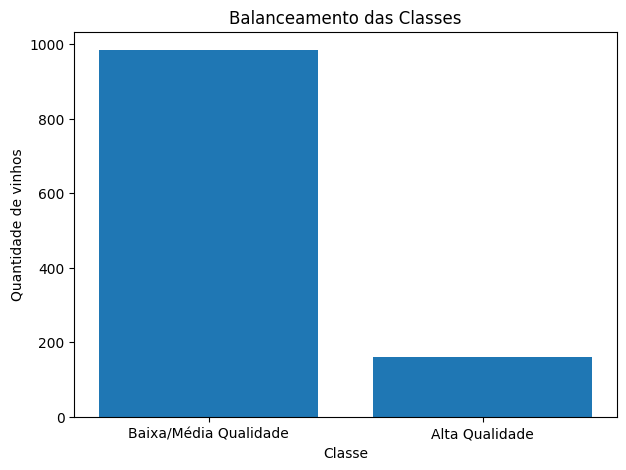

In [17]:
# Gráfico do balanceamento das classes

plt.figure(figsize=(7, 5))
plt.bar(["Baixa/Média Qualidade", "Alta Qualidade"], distribuicao_alta_qualidade.values)
plt.title("Balanceamento das Classes")
plt.xlabel("Classe")
plt.ylabel("Quantidade de vinhos")
plt.show()

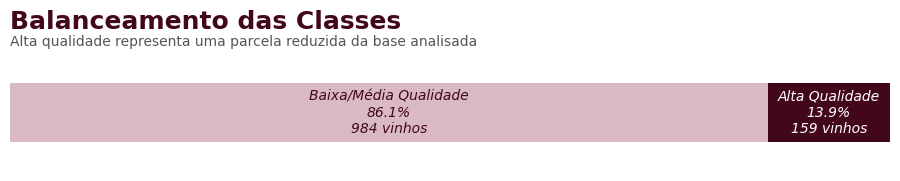

In [18]:
# Gráfico executivo - Balanceamento percentual das classes

cor_principal = "#43071b"
cor_secundaria = "#d8b9c5"
cor_texto = "#333333"

# Preparando os dados
distribuicao_alta_qualidade = df["alta_qualidade"].value_counts().sort_index()

qtd_baixa_media = distribuicao_alta_qualidade[0]
qtd_alta = distribuicao_alta_qualidade[1]
total = qtd_baixa_media + qtd_alta

perc_baixa_media = qtd_baixa_media / total * 100
perc_alta = qtd_alta / total * 100

# Criando figura com espaço controlado
fig = plt.figure(figsize=(10, 4.2), facecolor="white")

# Título e subtítulo posicionados manualmente para evitar sobreposição
fig.text(
    0.06,
    0.92,
    "Balanceamento das Classes",
    fontsize=18,
    fontweight="bold",
    color=cor_principal,
    ha="left"
)

fig.text(
    0.06,
    0.88,
    "Alta qualidade representa uma parcela reduzida da base analisada",
    fontsize=10,
    color="#555555",
    ha="left"
)

# Área do gráfico
ax = fig.add_axes([0.06, 0.58, 0.88, 0.28])

# Barra horizontal 100%
ax.barh(
    y=0,
    width=perc_baixa_media,
    color=cor_secundaria,
    height=0.5
)

ax.barh(
    y=0,
    width=perc_alta,
    left=perc_baixa_media,
    color=cor_principal,
    height=0.5
)

# Rótulo da classe baixa/média
ax.text(
    perc_baixa_media / 2,
    0,
    f"Baixa/Média Qualidade\n{perc_baixa_media:.1f}%\n{qtd_baixa_media} vinhos",
    ha="center",
    va="center",
    fontsize=10,
    fontweight="normal",
    fontstyle="italic",
    color=cor_principal
)

# Rótulo da classe alta qualidade
ax.text(
    perc_baixa_media + perc_alta / 2,
    0,
    f"Alta Qualidade\n{perc_alta:.1f}%\n{qtd_alta} vinhos",
    ha="center",
    va="center",
    fontsize=10,
    fontweight="normal",
    fontstyle="italic",
    color="white"
)

# Ajustes visuais
ax.set_xlim(0, 100)
ax.set_ylim(-0.5, 0.5)

ax.set_xticks([])
ax.set_yticks([])

for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_facecolor("white")

# Salvando imagem para usar no PowerPoint
plt.savefig(
    "../results/balanceamento_classes_executivo.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

In [19]:
# Distribuição percentual das classes

(df["alta_qualidade"].value_counts(normalize=True).sort_index() * 100).round(2)

alta_qualidade
0    86.09
1    13.91
Name: proportion, dtype: float64

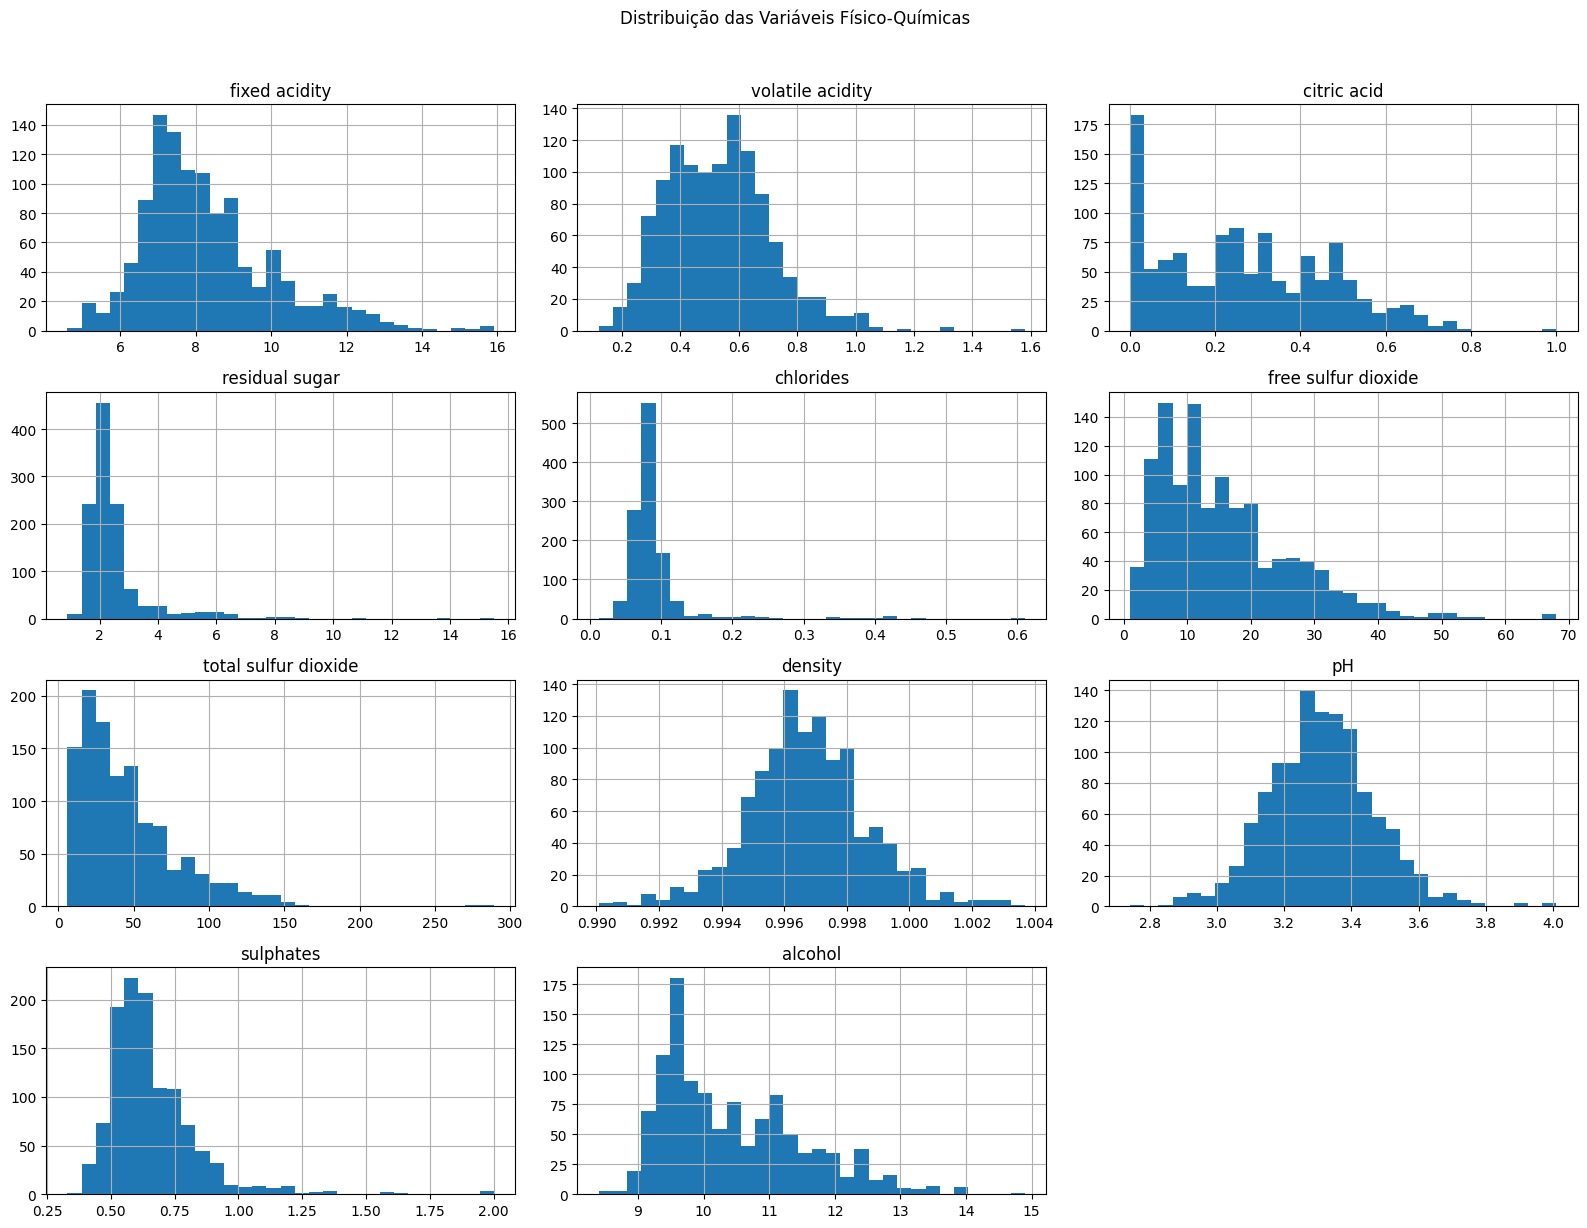

In [20]:
# Histogramas das variáveis físico-químicas

df[variaveis].hist(figsize=(16, 12), bins=30)
plt.suptitle("Distribuição das Variáveis Físico-Químicas", y=1.02)
plt.tight_layout()
plt.show()

In [21]:
# Matriz de correlação

dados_correlacao = df[variaveis + ["quality", "alta_qualidade"]]

correlacao = dados_correlacao.corr()

correlacao.round(2)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,alta_qualidade
fixed acidity,1.00,-0.25,0.67,0.17,0.11,-0.16,-0.11,0.68,-0.69,0.17,-0.08,0.12,0.12
volatile acidity,-0.25,1.00,-0.54,-0.01,0.06,-0.00,0.08,0.02,0.22,-0.28,-0.20,-0.41,-0.30
citric acid,0.67,-0.54,1.00,0.18,0.25,-0.06,0.04,0.38,-0.55,0.33,0.11,0.24,0.25
residual sugar,0.17,-0.01,0.18,1.00,0.07,0.17,0.19,0.38,-0.12,0.02,0.06,0.02,0.06
chlorides,0.11,0.06,0.25,0.07,1.00,0.02,0.05,0.21,-0.28,0.37,-0.23,-0.12,-0.10
free sulfur dioxide,-0.16,-0.00,-0.06,0.17,0.02,1.00,0.66,-0.05,0.07,0.03,-0.05,-0.06,-0.06
total sulfur dioxide,-0.11,0.08,0.04,0.19,0.05,0.66,1.00,0.05,-0.06,0.03,-0.19,-0.18,-0.11
density,0.68,0.02,0.38,0.38,0.21,-0.05,0.05,1.00,-0.35,0.14,-0.49,-0.18,-0.15
pH,-0.69,0.22,-0.55,-0.12,-0.28,0.07,-0.06,-0.35,1.00,-0.19,0.23,-0.05,-0.07
sulphates,0.17,-0.28,0.33,0.02,0.37,0.03,0.03,0.14,-0.19,1.00,0.09,0.26,0.21


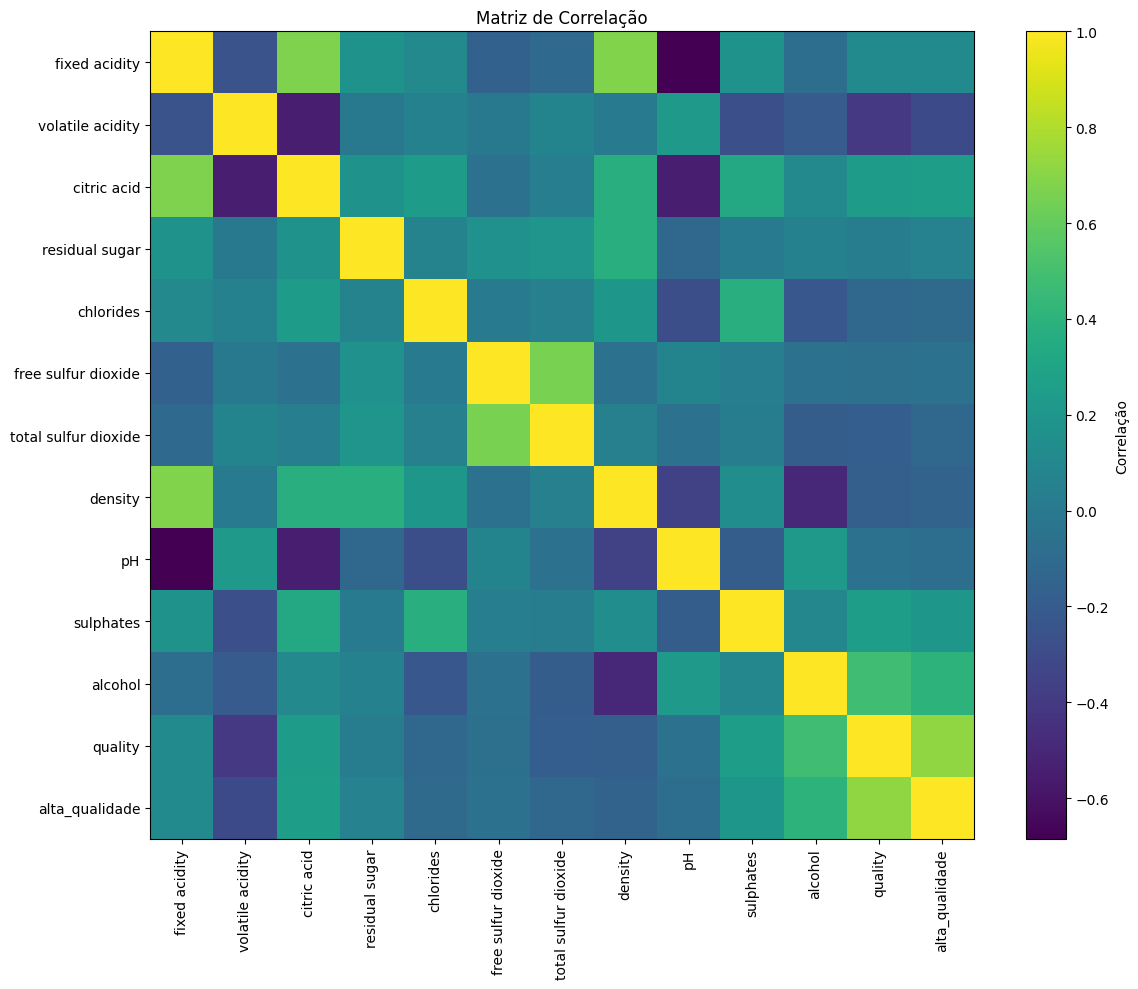

In [22]:
# Gráfico da matriz de correlação

plt.figure(figsize=(12, 10))
plt.imshow(correlacao, aspect="auto")
plt.colorbar(label="Correlação")

plt.xticks(range(len(correlacao.columns)), correlacao.columns, rotation=90)
plt.yticks(range(len(correlacao.columns)), correlacao.columns)

plt.title("Matriz de Correlação")
plt.tight_layout()
plt.show()

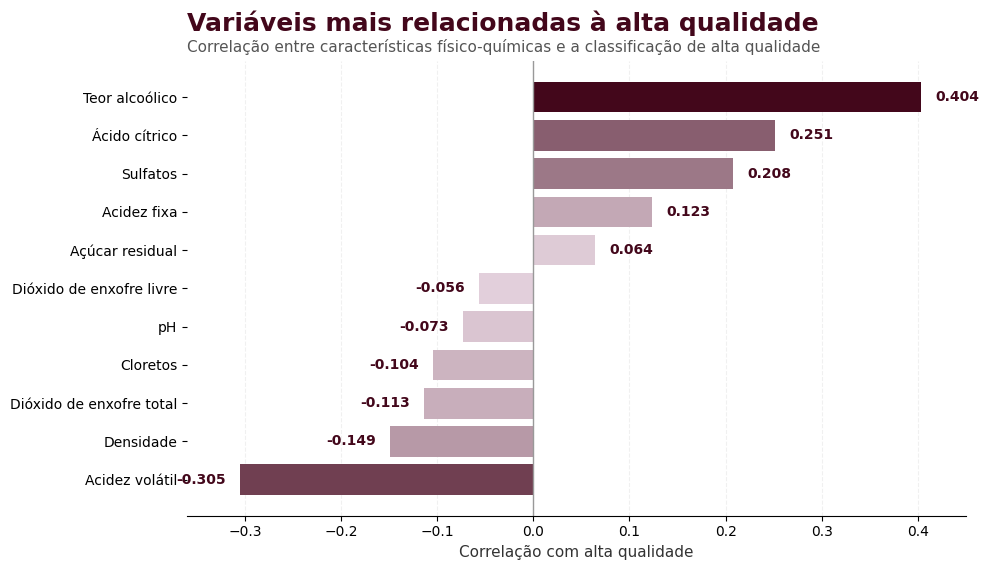

In [23]:
# Matriz executiva - Correlação com Alta Qualidade

from matplotlib.colors import LinearSegmentedColormap
import numpy as np
import matplotlib.pyplot as plt

cor_principal = "#43071b"
cor_clara = "#fbeff9"
cor_texto = "#333333"

# Correlação das variáveis com a variável alvo
correlacao_alta_qualidade = (
    df[variaveis + ["alta_qualidade"]]
    .corr()["alta_qualidade"]
    .drop("alta_qualidade")
    .sort_values(ascending=True)
)

# Nomes amigáveis para apresentação
nomes_variaveis = {
    "alcohol": "Teor alcoólico",
    "sulphates": "Sulfatos",
    "volatile acidity": "Acidez volátil",
    "density": "Densidade",
    "total sulfur dioxide": "Dióxido de enxofre total",
    "chlorides": "Cloretos",
    "citric acid": "Ácido cítrico",
    "fixed acidity": "Acidez fixa",
    "pH": "pH",
    "residual sugar": "Açúcar residual",
    "free sulfur dioxide": "Dióxido de enxofre livre"
}

correlacao_plot = correlacao_alta_qualidade.reset_index()
correlacao_plot.columns = ["variavel", "correlacao"]
correlacao_plot["variavel_formatada"] = correlacao_plot["variavel"].map(nomes_variaveis)

# Criando escala de cor entre claro e vinho
cmap = LinearSegmentedColormap.from_list(
    "vinho_scale",
    [cor_clara, cor_principal]
)

# Intensidade da cor pela força da correlação absoluta
intensidade = np.abs(correlacao_plot["correlacao"])
cores = cmap(intensidade / intensidade.max())

# Criando figura
fig, ax = plt.subplots(figsize=(10, 5.8), facecolor="white")

barras = ax.barh(
    correlacao_plot["variavel_formatada"],
    correlacao_plot["correlacao"],
    color=cores,
    edgecolor="none"
)

# Linha central em zero
ax.axvline(0, color="#999999", linewidth=1)

# Rótulos nas barras
for barra, valor in zip(barras, correlacao_plot["correlacao"]):
    largura = barra.get_width()
    
    if valor >= 0:
        x_texto = largura + 0.015
        ha = "left"
    else:
        x_texto = largura - 0.015
        ha = "right"
    
    ax.text(
        x_texto,
        barra.get_y() + barra.get_height() / 2,
        f"{valor:.3f}",
        va="center",
        ha=ha,
        fontsize=10,
        fontweight="bold",
        color=cor_principal
    )

# Título
ax.set_title(
    "Variáveis mais relacionadas à alta qualidade",
    fontsize=18,
    fontweight="bold",
    color=cor_principal,
    loc="left",
    pad=22
)

# Subtítulo
ax.text(
    0,
    1.02,
    "Correlação entre características físico-químicas e a classificação de alta qualidade",
    transform=ax.transAxes,
    fontsize=11,
    color="#555555"
)

# Ajustes visuais
ax.set_xlabel("Correlação com alta qualidade", fontsize=11, color=cor_texto)
ax.set_ylabel("")

ax.grid(axis="x", linestyle="--", alpha=0.18)
ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

# Limites para equilibrar positivos e negativos
ax.set_xlim(-0.36, 0.45)

fig.patch.set_facecolor("white")
ax.set_facecolor("white")

plt.tight_layout()

# Salvando para uso no PowerPoint
plt.savefig(
    "../results/correlacao_alta_qualidade_executivo.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

In [24]:
# Correlação das variáveis físico-químicas com a variável alvo

correlacao_alta_qualidade = (
    df[variaveis + ["alta_qualidade"]]
    .corr()["alta_qualidade"]
    .drop("alta_qualidade")
    .sort_values(ascending=False)
)

correlacao_alta_qualidade.round(3)

alcohol                 0.404
citric acid             0.251
sulphates               0.208
fixed acidity           0.123
residual sugar          0.064
free sulfur dioxide    -0.056
pH                     -0.073
chlorides              -0.104
total sulfur dioxide   -0.113
density                -0.149
volatile acidity       -0.305
Name: alta_qualidade, dtype: float64

In [25]:
# Comparação das médias das variáveis por classe

medias_por_classe = df.groupby("alta_qualidade")[variaveis].mean().T

medias_por_classe.columns = ["Baixa/Média Qualidade", "Alta Qualidade"]

medias_por_classe["Diferença"] = (
    medias_por_classe["Alta Qualidade"] - medias_por_classe["Baixa/Média Qualidade"]
)

medias_por_classe.round(3)

,Baixa/Média Qualidade,Alta Qualidade,Diferença
fixed acidity,8.225,8.847,0.622
volatile acidity,0.553,0.395,-0.158
citric acid,0.249,0.391,0.143
residual sugar,2.497,2.748,0.251
chlorides,0.089,0.075,-0.014
free sulfur dioxide,15.846,14.189,-1.657
total sulfur dioxide,47.408,36.673,-10.735
density,0.997,0.996,-0.001
pH,3.316,3.282,-0.033
sulphates,0.643,0.746,0.102


In [26]:
# Identificação de possíveis outliers pelo método do intervalo interquartil (IQR)

outliers = []

for coluna in variaveis:
    q1 = df[coluna].quantile(0.25)
    q3 = df[coluna].quantile(0.75)
    iqr = q3 - q1
    
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    
    qtd_outliers = df[
        (df[coluna] < limite_inferior) | 
        (df[coluna] > limite_superior)
    ].shape[0]
    
    percentual_outliers = qtd_outliers / df.shape[0] * 100
    
    outliers.append({
        "variavel": coluna,
        "limite_inferior": limite_inferior,
        "limite_superior": limite_superior,
        "qtd_outliers": qtd_outliers,
        "percentual_outliers": percentual_outliers
    })

df_outliers = pd.DataFrame(outliers)

df_outliers.sort_values(by="qtd_outliers", ascending=False).round(2)

,variavel,limite_inferior,limite_superior,qtd_outliers,percentual_outliers
3,residual sugar,0.85,3.65,110,9.62
4,chlorides,0.04,0.12,77,6.74
0,fixed acidity,4.10,12.10,44,3.85
9,sulphates,0.28,1.00,43,3.76
6,total sulfur dioxide,-39.00,121.00,40,3.50
7,density,0.99,1.00,36,3.15
8,pH,2.91,3.69,20,1.75
5,free sulfur dioxide,-14.00,42.00,18,1.57
1,volatile acidity,0.02,1.01,14,1.22
10,alcohol,7.10,13.50,12,1.05


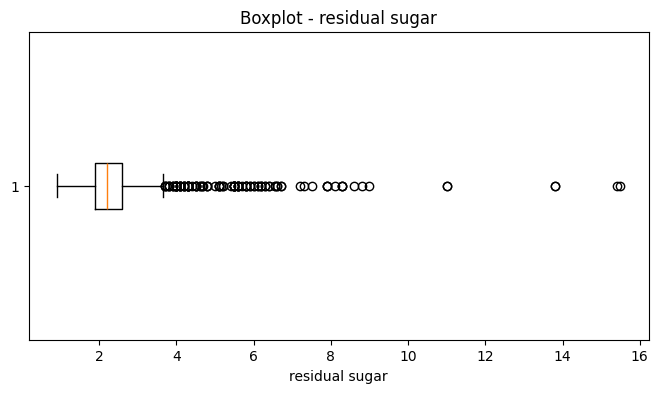

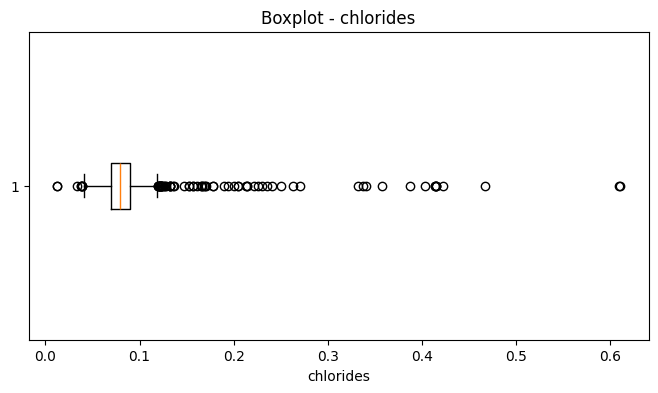

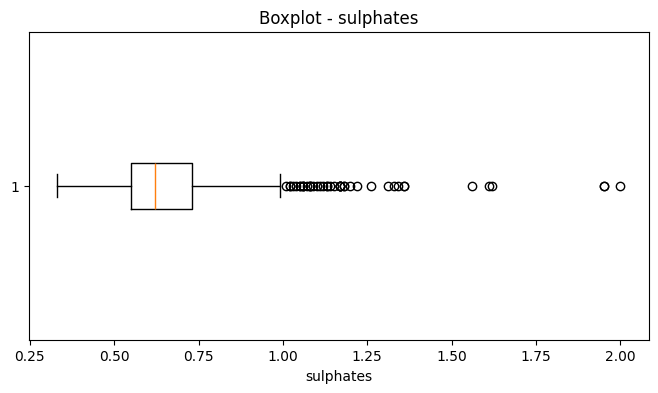

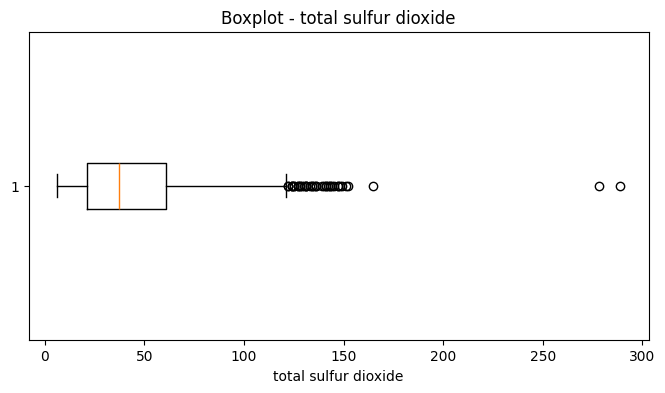

In [27]:
# Boxplots das variáveis com maior presença de possíveis outliers

variaveis_outliers = [
    "residual sugar",
    "chlorides",
    "sulphates",
    "total sulfur dioxide"
]

for coluna in variaveis_outliers:
    plt.figure(figsize=(8, 4))
    plt.boxplot(df[coluna], vert=False)
    plt.title(f"Boxplot - {coluna}")
    plt.xlabel(coluna)
    plt.show()

### Conclusões da Análise Exploratória

A análise exploratória mostrou que a maior parte dos vinhos da base recebeu notas intermediárias, principalmente entre 5 e 6. Após a transformação da variável `quality` em uma classificação binária, observou-se um desbalanceamento relevante entre as classes: a maior parte dos registros pertence à classe de baixa/média qualidade, enquanto a classe de alta qualidade representa uma parcela menor da base.

Na análise de correlação, as variáveis que apresentaram maior relação positiva com a classificação de alta qualidade foram `alcohol`, `citric acid` e `sulphates`. Isso indica que vinhos com maior teor alcoólico, maior presença de ácido cítrico e maior teor de sulfatos tendem a estar mais associados a avaliações superiores.

Por outro lado, a variável `volatile acidity` apresentou correlação negativa com a alta qualidade, sugerindo que vinhos com maior acidez volátil tendem a receber avaliações inferiores. Variáveis como `density`, `total sulfur dioxide` e `chlorides` também apresentaram relação negativa com a classificação de alta qualidade.

Também foram identificados possíveis outliers em algumas variáveis, especialmente em `residual sugar`, `chlorides`, `sulphates` e `total sulfur dioxide`. Esses valores serão mantidos inicialmente na base, pois podem representar variações reais nas características físico-químicas dos vinhos. Na etapa de modelagem, serão utilizados algoritmos capazes de lidar melhor com esse tipo de variação.


## 3. Pré-processamento dos Dados

Nesta etapa, os dados serão preparados para a construção dos modelos de Machine Learning.

Primeiro, serão separadas as variáveis explicativas, chamadas de `X`, e a variável alvo, chamada de `y`.

As variáveis explicativas são as características físico-químicas dos vinhos, como acidez, densidade, pH, sulfatos e teor alcoólico. A variável alvo será `alta_qualidade`, criada anteriormente a partir da nota original `quality`.

A coluna `Id` não será utilizada como variável preditora, pois representa apenas um identificador da amostra. A coluna `quality` também não será utilizada como entrada do modelo, pois ela foi usada para construir a variável alvo. Se o modelo tivesse acesso à nota original, ele estaria recebendo a resposta diretamente, o que invalidaria o processo de aprendizado.

In [28]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [29]:
# Importação das bibliotecas de pré-processamento

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [30]:
# Separação entre variáveis explicativas (X) e variável alvo (y)

X = df.drop(columns=["Id", "quality", "alta_qualidade"])
y = df["alta_qualidade"]

In [31]:
# Visualizando as variáveis que serão usadas pelo modelo

X.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4


In [32]:
# Visualizando a variável alvo

y.head()

0    0
1    0
2    0
3    0
4    0
Name: alta_qualidade, dtype: int64

In [33]:
# Conferindo as dimensões de X e y

print("Tamanho de X:", X.shape)
print("Tamanho de y:", y.shape)

Tamanho de X: (1143, 11)
Tamanho de y: (1143,)


In [34]:
# Divisão da base em treino e teste

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [35]:
test_size=0.2

In [36]:
random_state=42

In [37]:
random_state=42

In [38]:
# Conferindo o tamanho das bases de treino e teste

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (914, 11)
X_test: (229, 11)
y_train: (914,)
y_test: (229,)


In [39]:
# Verificando a proporção das classes na base original, treino e teste

print("Base original:")
print(y.value_counts(normalize=True).round(3))

print("\nBase de treino:")
print(y_train.value_counts(normalize=True).round(3))

print("\nBase de teste:")
print(y_test.value_counts(normalize=True).round(3))

Base original:
alta_qualidade
0    0.861
1    0.139
Name: proportion, dtype: float64

Base de treino:
alta_qualidade
0    0.861
1    0.139
Name: proportion, dtype: float64

Base de teste:
alta_qualidade
0    0.86
1    0.14
Name: proportion, dtype: float64


In [40]:
# Padronização das variáveis numéricas

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [41]:
# Convertendo os dados padronizados para DataFrame

X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X.columns,
    index=X_test.index
)

X_train_scaled.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
951,-1.320971,-0.165638,-1.400862,-0.804309,-0.677051,-0.024763,-0.580648,-1.162557,0.317862,-1.240228,-0.868305
221,1.124820,-0.681264,0.772796,-0.107462,3.055419,-0.928089,-0.942127,1.360502,-0.777490,-0.217749,-0.868305
180,0.612910,-1.082306,0.514027,-0.246832,-0.246381,-1.028459,-0.972250,0.642558,-0.584193,-0.217749,-1.144489
88,-0.126515,4.589577,-1.400862,-0.525570,-0.078898,-1.229198,-1.002373,-0.177949,1.477647,-1.059790,0.420555
1094,-0.638425,0.006237,-0.728063,-0.386201,-0.653125,0.276346,-0.701141,-0.521536,-0.648625,0.143126,-0.500059


Nesta etapa, a base foi preparada para a modelagem. As variáveis físico-químicas foram separadas como variáveis explicativas (`X`), enquanto a variável `alta_qualidade` foi definida como variável alvo (`y`).

As colunas `Id`, `quality` e `alta_qualidade` foram removidas das variáveis de entrada. A coluna `Id` não representa uma característica do vinho, enquanto `quality` e `alta_qualidade` estão diretamente relacionadas à resposta que o modelo deve prever.

Em seguida, a base foi dividida em treino e teste, utilizando 80% dos dados para treinamento e 20% para avaliação. A divisão foi feita de forma estratificada, preservando a proporção entre vinhos de alta qualidade e baixa/média qualidade nas duas bases.

Por fim, as variáveis numéricas foram padronizadas com `StandardScaler`, garantindo que todas ficassem em uma escala comparável para os modelos de Machine Learning.

## 4. Desenvolvimento de Modelos

Nesta etapa, serão treinados dois modelos de classificação para prever se um vinho pertence à classe de alta qualidade ou baixa/média qualidade.

Os modelos escolhidos foram:

* Regressão Logística: modelo estatístico simples, interpretável e útil como referência inicial;
* Random Forest: modelo baseado em múltiplas árvores de decisão, capaz de capturar relações mais complexas entre as variáveis.

Como a base apresenta desbalanceamento entre as classes, os modelos serão treinados considerando esse fator, de forma a reduzir a tendência de priorizar apenas a classe majoritária.


In [42]:
# Importação dos modelos e métricas de avaliação

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [43]:
# Treinamento do modelo de Regressão Logística

modelo_logistico = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=123
)

modelo_logistico.fit(X_train_scaled, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",123
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default

In [44]:
# Previsões da Regressão Logística

y_pred_logistico = modelo_logistico.predict(X_test_scaled)

y_proba_logistico = modelo_logistico.predict_proba(X_test_scaled)[:, 1]

In [45]:
# Treinamento do modelo Random Forest

modelo_random_forest = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=123,
    n_jobs=-1
)

modelo_random_forest.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",123
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_f

In [46]:
# Previsões do Random Forest

y_pred_rf = modelo_random_forest.predict(X_test)

y_proba_rf = modelo_random_forest.predict_proba(X_test)[:, 1]

## 5. Avaliação dos Modelos

In [47]:
# Função para avaliação dos modelos

def avaliar_modelo(nome_modelo, y_real, y_pred, y_proba):
    return {
        "Modelo": nome_modelo,
        "Acurácia": accuracy_score(y_real, y_pred),
        "Precision": precision_score(y_real, y_pred, zero_division=0),
        "Recall": recall_score(y_real, y_pred, zero_division=0),
        "F1-score": f1_score(y_real, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_real, y_proba)
    }

In [48]:
# Comparação dos modelos

resultados_modelos = pd.DataFrame([
    avaliar_modelo(
        "Regressão Logística",
        y_test,
        y_pred_logistico,
        y_proba_logistico
    ),
    avaliar_modelo(
        "Random Forest",
        y_test,
        y_pred_rf,
        y_proba_rf
    )
])

resultados_modelos.round(3)

,Modelo,Acurácia,Precision,Recall,F1-score,ROC-AUC
0,Regressão Logística,0.799,0.379,0.688,0.489,0.850
1,Random Forest,0.900,0.629,0.688,0.657,0.918


In [49]:
# Relatório de classificação - Regressão Logística

print(classification_report(
    y_test,
    y_pred_logistico,
    target_names=["Baixa/Média Qualidade", "Alta Qualidade"],
    zero_division=0
))

                       precision    recall  f1-score   support

Baixa/Média Qualidade       0.94      0.82      0.88       197
       Alta Qualidade       0.38      0.69      0.49        32

             accuracy                           0.80       229
            macro avg       0.66      0.75      0.68       229
         weighted avg       0.86      0.80      0.82       229



In [50]:
# Relatório de classificação - Random Forest

print(classification_report(
    y_test,
    y_pred_rf,
    target_names=["Baixa/Média Qualidade", "Alta Qualidade"],
    zero_division=0
))

                       precision    recall  f1-score   support

Baixa/Média Qualidade       0.95      0.93      0.94       197
       Alta Qualidade       0.63      0.69      0.66        32

             accuracy                           0.90       229
            macro avg       0.79      0.81      0.80       229
         weighted avg       0.90      0.90      0.90       229



In [51]:
# Função para exibir a matriz de confusão

def exibir_matriz_confusao(y_real, y_pred):
    matriz = confusion_matrix(y_real, y_pred)
    
    return pd.DataFrame(
        matriz,
        index=["Real: Baixa/Média", "Real: Alta"],
        columns=["Previsto: Baixa/Média", "Previsto: Alta"]
    )

In [52]:
# Matriz de confusão - Regressão Logística

exibir_matriz_confusao(y_test, y_pred_logistico)

,Previsto: Baixa/Média,Previsto: Alta
Real: Baixa/Média,161,36
Real: Alta,10,22


In [53]:
# Matriz de confusão - Random Forest

exibir_matriz_confusao(y_test, y_pred_rf)

,Previsto: Baixa/Média,Previsto: Alta
Real: Baixa/Média,184,13
Real: Alta,10,22


In [54]:
resultados_modelos.round(3)

,Modelo,Acurácia,Precision,Recall,F1-score,ROC-AUC
0,Regressão Logística,0.799,0.379,0.688,0.489,0.850
1,Random Forest,0.900,0.629,0.688,0.657,0.918


Os dois modelos foram treinados e avaliados com as mesmas bases de treino e teste.

A Regressão Logística apresentou um recall maior para a classe de alta qualidade, indicando maior capacidade de identificar vinhos realmente classificados como superiores. No entanto, sua precision foi menor, o que indica maior quantidade de falsos positivos.

O Random Forest apresentou melhor desempenho geral, com maior acurácia, maior precision, maior F1-score e maior ROC-AUC. Isso indica que o modelo conseguiu equilibrar melhor a identificação dos vinhos de alta qualidade com uma menor taxa de erro.

Dessa forma, considerando o conjunto das métricas avaliadas, o Random Forest apresentou o melhor desempenho entre os modelos testados.

## 6. Interpretação dos Resultados

In [55]:
# Importância das variáveis no modelo Random Forest

importancias = pd.DataFrame({
    "variavel": X.columns,
    "importancia": modelo_random_forest.feature_importances_
})

importancias = importancias.sort_values(by="importancia", ascending=False)

importancias.round(3)

,variavel,importancia
10,alcohol,0.209
9,sulphates,0.138
2,citric acid,0.138
1,volatile acidity,0.111
7,density,0.075
6,total sulfur dioxide,0.068
0,fixed acidity,0.063
4,chlorides,0.054
8,pH,0.053
3,residual sugar,0.047


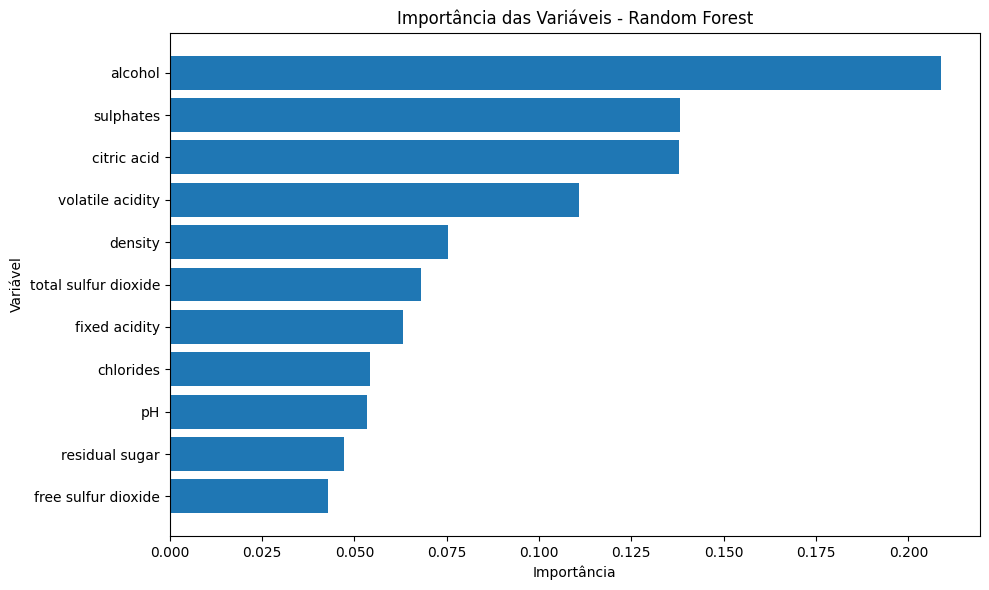

In [56]:
# Gráfico de importância das variáveis

plt.figure(figsize=(10, 6))
plt.barh(importancias["variavel"], importancias["importancia"])
plt.gca().invert_yaxis()
plt.title("Importância das Variáveis - Random Forest")
plt.xlabel("Importância")
plt.ylabel("Variável")
plt.tight_layout()
plt.show()

A análise de importância das variáveis do modelo Random Forest indica quais características físico-químicas mais contribuíram para a classificação dos vinhos.

Entre as variáveis mais relevantes, destacam-se o teor alcoólico (`alcohol`), os sulfatos (`sulphates`), o ácido cítrico (`citric acid`), a acidez volátil (`volatile acidity`), a densidade (`density`) e o dióxido de enxofre total (`total sulfur dioxide`).

Esses resultados estão alinhados com a análise exploratória realizada anteriormente, na qual o teor alcoólico apresentou associação positiva com a alta qualidade, enquanto a acidez volátil apresentou associação negativa.

É importante destacar que a importância das variáveis não significa causalidade. Ou seja, o modelo identifica padrões estatísticos na base analisada, mas não permite afirmar isoladamente que uma variável causa diretamente maior ou menor qualidade. Ainda assim, esses resultados podem apoiar análises técnicas e decisões no processo produtivo.

In [57]:
# Salvando a tabela de métricas dos modelos

resultados_modelos.round(3).to_csv("../results/resultados_modelos.csv", index=False)

# Salvando a tabela de importância das variáveis

importancias.round(3).to_csv("../results/importancia_variaveis_random_forest.csv", index=False)

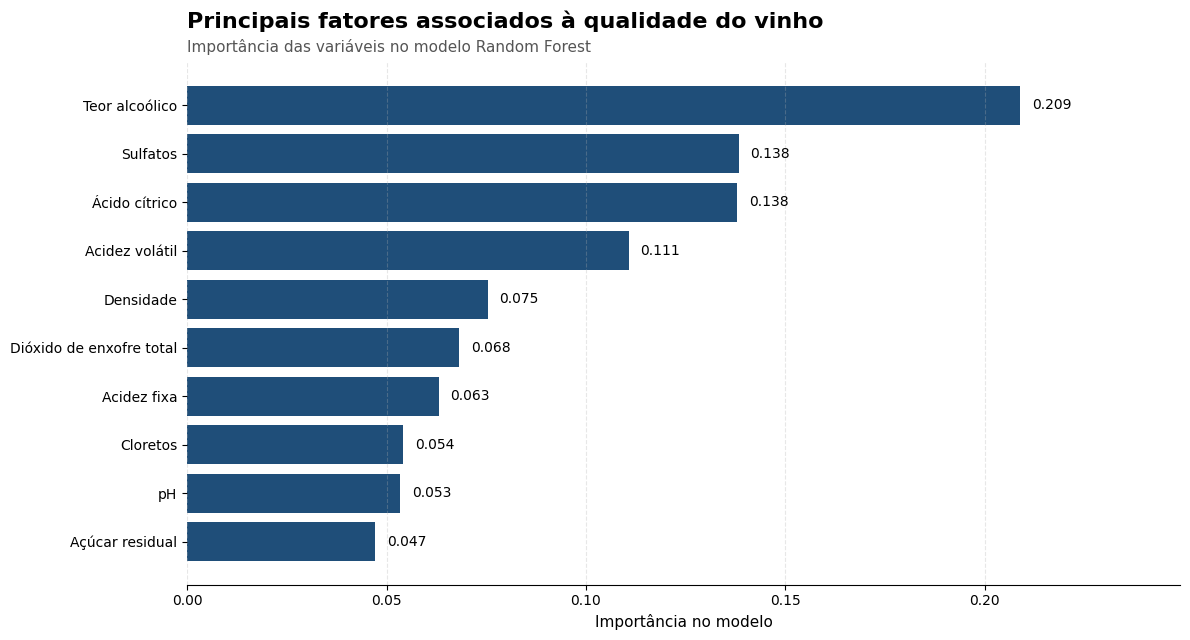

In [58]:
# Gráfico executivo de importância das variáveis - Random Forest

# Dicionário para deixar os nomes das variáveis mais amigáveis
nomes_variaveis = {
    "alcohol": "Teor alcoólico",
    "sulphates": "Sulfatos",
    "volatile acidity": "Acidez volátil",
    "density": "Densidade",
    "total sulfur dioxide": "Dióxido de enxofre total",
    "chlorides": "Cloretos",
    "citric acid": "Ácido cítrico",
    "fixed acidity": "Acidez fixa",
    "pH": "pH",
    "residual sugar": "Açúcar residual",
    "free sulfur dioxide": "Dióxido de enxofre livre"
}

# Preparando a base para o gráfico
importancias_plot = importancias.copy()
importancias_plot["variavel_formatada"] = importancias_plot["variavel"].map(nomes_variaveis)

# Selecionando as 10 variáveis mais importantes
importancias_plot = importancias_plot.head(10).sort_values("importancia", ascending=True)

# Criando figura e eixo
fig, ax = plt.subplots(figsize=(12, 6.5))

# Criando barras
barras = ax.barh(
    importancias_plot["variavel_formatada"],
    importancias_plot["importancia"],
    color="#1f4e79"
)

# Adicionando valores ao final das barras
for barra in barras:
    largura = barra.get_width()
    ax.text(
        largura + 0.003,
        barra.get_y() + barra.get_height() / 2,
        f"{largura:.3f}",
        va="center",
        fontsize=10
    )

# Título principal
ax.set_title(
    "Principais fatores associados à qualidade do vinho",
    fontsize=16,
    fontweight="bold",
    loc="left",
    pad=25
)

# Subtítulo
ax.text(
    0,
    1.02,
    "Importância das variáveis no modelo Random Forest",
    transform=ax.transAxes,
    fontsize=11,
    color="#555555"
)

# Ajustes dos eixos
ax.set_xlabel("Importância no modelo", fontsize=11)
ax.set_ylabel("")

# Grade suave
ax.grid(axis="x", linestyle="--", alpha=0.3)

# Removendo bordas desnecessárias
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

# Ajuste do limite do eixo X para não cortar os rótulos
ax.set_xlim(0, importancias_plot["importancia"].max() + 0.04)

plt.tight_layout()

# Salvando o gráfico
plt.savefig(
    "../results/importancia_variaveis_random_forest_executivo.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

A análise de importância das variáveis indica que o teor alcoólico foi o principal fator considerado pelo modelo Random Forest para classificar a qualidade dos vinhos. Em seguida, destacaram-se sulfatos, ácido cítrico e acidez volátil.

Esses resultados sugerem que a classificação de alta qualidade não depende de uma única característica isolada, mas de uma combinação de fatores físico-químicos. Ainda assim, o teor alcoólico apresentou maior relevância relativa no modelo, reforçando sua associação com vinhos melhor avaliados na base analisada.

## 7. Conclusão Final

O objetivo deste projeto foi desenvolver um modelo de classificação capaz de prever se um vinho pode ser considerado de alta qualidade ou de baixa/média qualidade com base em suas características físico-químicas.

Para isso, a variável original `quality` foi transformada em uma variável binária chamada `alta_qualidade`, considerando como vinhos de alta qualidade aqueles com nota maior ou igual a 7, e como baixa/média qualidade os vinhos com nota inferior a 7.

Durante a análise exploratória, foi identificado que a base apresenta desbalanceamento entre as classes, com predominância de vinhos classificados como baixa/média qualidade. Também foi observado que algumas variáveis, como `alcohol`, `citric acid`, `sulphates` e `volatile acidity`, apresentam maior relação com a classificação de qualidade.

Na etapa de modelagem, foram testados dois modelos de classificação: Regressão Logística e Random Forest. Ambos foram avaliados com métricas adequadas para problemas de classificação desbalanceada, como acurácia, precision, recall, F1-score, ROC-AUC e matriz de confusão.

A Regressão Logística apresentou bom recall para a classe de alta qualidade, conseguindo identificar parte relevante dos vinhos superiores. No entanto, apresentou maior quantidade de falsos positivos, classificando mais vinhos de baixa/média qualidade como se fossem de alta qualidade.

O modelo Random Forest apresentou o melhor desempenho geral. Ele obteve maior acurácia, maior precision, maior F1-score e maior ROC-AUC, mantendo o mesmo recall da Regressão Logística para a classe de alta qualidade. Isso significa que o modelo conseguiu identificar a mesma proporção de vinhos de alta qualidade, mas com menor quantidade de classificações incorretas.

A análise de importância das variáveis indicou que o teor alcoólico foi o principal fator considerado pelo modelo Random Forest para classificar a qualidade dos vinhos. Também se destacaram sulfatos, ácido cítrico e acidez volátil, reforçando que a qualidade do vinho está associada a uma combinação de características físico-químicas, e não a uma única variável isolada.

Do ponto de vista de negócio, o modelo pode apoiar produtores e especialistas na análise inicial da qualidade dos vinhos, contribuindo para decisões mais orientadas por dados durante o processo produtivo. No entanto, é importante destacar que o modelo não substitui a avaliação sensorial realizada por especialistas. Ele deve ser entendido como uma ferramenta complementar, capaz de indicar padrões e apoiar a tomada de decisão.

Portanto, considerando os resultados obtidos, o Random Forest foi selecionado como o melhor modelo entre os testados para este problema de classificação.
